# Bootstrap examples

`bootstrap` function can be used to bootstrap the zero coupon yields from coupon bonds available in the markets

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantpy.instruments.CouponBond import CouponBond
from quantpy.instruments.CouponBond import bootstrap
from quantpy import QuantDatetime

plt.style.use('seaborn-v0_8')
example_root = Path(os.path.abspath(""))

This bootstrap example uses the prices for bonds issued by the Republic of Finland. The prices of the bonds were sourced from Refinitiv and correspond with the close prices for 2026-02-02. The included bonds are bonds with euro denomination and investment grade rating

In [2]:
bond_df = pd.read_csv(example_root / "data" / "fi_bonds_2026-02-02.csv")
bond_df.head(5)

,RIC,Issuer,CouponRate,MaturityDate,IssueDate,ISIN,Currency,FaceValue,FaceIssuedUSD,CouponFrequencyDescription,NextCouponDate,Bid,Ask,AccruedInterest,MidYield,ModifiedDuration,DollarDuration,Convexity,Z-Spread,OIS-Spread
0,FI0197959=,"Finland, Republic of (Government)",0.500,2026-04-15,2016-03-08,FI4000197959,EUR,100,8325184094,Annually,2026-04-15,99.640,99.780,0.4041,2.0098,0.1910,0.1910,0.0730,35.7209,7.8498
1,FI0511449=,"Finland, Republic of (Government)",0.000,2026-09-15,2021-08-31,FI4000511449,EUR,100,4706921944,Annually,2026-09-15,98.720,98.880,0.0000,1.9880,0.6036,0.5964,0.7287,-6.5401,6.2920
2,FI0527551=,"Finland, Republic of (Government)",1.375,2027-04-15,2022-08-30,FI4000527551,EUR,100,5098085419,Annually,2026-04-15,99.150,99.290,1.1113,2.0423,1.1546,1.1584,2.4774,-4.3820,11.4742
3,FI0278551=,"Finland, Republic of (Government)",0.500,2027-09-15,2017-09-06,FI4000278551,EUR,100,8144918998,Annually,2026-09-15,97.400,97.560,0.1945,2.1066,1.5728,1.5360,4.0188,-0.3450,15.4949
4,FI0037635=,"Finland, Republic of (Government)",2.750,2028-07-04,2012-02-07,FI4000037635,EUR,100,6244477172,Annually,2026-07-04,101.377,101.427,1.6199,2.1441,2.2832,2.3522,7.5685,-15.0969,11.6388


In [3]:
current_date = QuantDatetime(2026, 2, 2, calendar="London", convention="ACT/360")
bonds  = []
prices = []

for _, row in bond_df.iterrows():
  issuance_date = QuantDatetime(*tuple(map(int, row["IssueDate"].split('-'))), calendar="London", convention="ACT/360")
  maturity_date = QuantDatetime(*tuple(map(int, row["MaturityDate"].split('-'))), calendar="London", convention="ACT/360")
  coupon_rate   = float(row["CouponRate"]) / 100.
  coupon_freq   = 1
  notional      = float(row["FaceValue"])
  mid_price     = (float(row["Bid"]) + float(row["Ask"])) / 2. + float(row["AccruedInterest"])
  
  bonds.append(CouponBond(issuance_date, maturity_date, coupon_rate, notional, coupon_freq))
  prices.append(mid_price)
  
print(repr(bonds[0]))

Maturity date: 2026-04-15 16:00:00.000
Notional: 100.0
Coupon rate: 0.005
Coupon frequency: 1
Issuance date: 2016-03-08 16:00:00.000
Zero pricer: Discount


In [4]:
print(bonds[0].zeros)

[Maturity date: 2026-04-15 16:00:00.000
Notional: 100.49999999999999
Pricer: Discount, Maturity date: 2025-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2024-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2023-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2022-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2021-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2020-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2019-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2018-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2017-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount]


Note that commonly applied day-count convention with coupon bearing bonds is `ACT/360`

Having defined the bonds and their prices the `bootstrap` function can be used

In [5]:
tup_arr = bootstrap(current_date, bonds, prices)

1.2138888888888888 1.4361111111111111 1.6388888888888888 0.5228758169934642

0.2 0.4222222222222222 0.625 0.5228758169934641

1.6388888888888888 2.2305555555555556 2.452777777777778 0.7269624573378839

1.6388888888888888 2.2305555555555556 2.452777777777778 0.7269624573378839

1.6388888888888888 2.2305555555555556 2.452777777777778 0.7269624573378839

1.6388888888888888 2.2305555555555556 2.452777777777778 0.7269624573378839

6.713888888888889 7.302777777777778 7.727777777777778 0.5808219178082196

1.6388888888888888 2.2305555555555556 2.452777777777778 0.7269624573378839

8.741666666666667 9.330555555555556 9.755555555555556 0.5808219178082187

6.713888888888889 7.302777777777778 7.727777777777778 0.5808219178082196

1.6388888888888888 2.2305555555555556 2.452777777777778 0.7269624573378839

10.347222222222221 11.36111111111111 12.375 0.5

8.741666666666667 9.330555555555556 9.755555555555556 0.5808219178082187

6.713888888888889 7.302777777777778 7.727777777777778 0.5808219178082196


In [6]:
tup_arr

[(0.2, np.float64(0.9961601990049753)),
 (0.625, np.float64(0.988)),
 (1.2138888888888888, np.float64(0.9761931415671334)),
 (1.6388888888888888, np.float64(0.9669701492537316)),
 (2.452777777777778, np.float64(0.9500801620540654)),
 (2.6555555555555554, np.float64(0.9435523873171459)),
 (3.2444444444444445, np.float64(0.9287319885149687)),
 (3.6694444444444443, np.float64(0.9179725246936774)),
 (4.258333333333334, np.float64(0.9018321005429216)),
 (4.683333333333334, np.float64(0.8902)),
 (5.272222222222222, np.float64(0.8735210224941701)),
 (5.697222222222222, np.float64(0.8622248501107806)),
 (6.288888888888889, np.float64(0.8348244372517375)),
 (6.713888888888889, np.float64(0.8326130062358326)),
 (7.727777777777778, np.float64(0.8021504975453059)),
 (8.316666666666666, np.float64(0.7851080506123125)),
 (8.741666666666667, np.float64(0.7711655315973843)),
 (9.755555555555556, np.float64(0.7404713899003733)),
 (10.347222222222221, np.float64(0.7229102715367642)),
 (12.375, np.float6

TODO: Fix the long end of bootstrapping

The found discount factors are

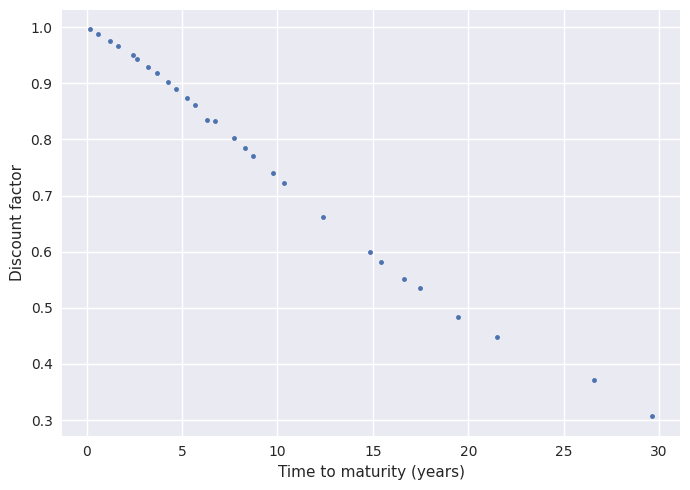

In [7]:
time_to_maturity = np.array([tup[0] for tup in tup_arr])
discount_factors = np.array([tup[1] for tup in tup_arr])

fig = plt.figure(figsize=(7, 5))

plt.plot(time_to_maturity, discount_factors, '.')
plt.ylabel("Discount factor")
plt.xlabel("Time to maturity (years)")

fig.tight_layout()

plt.show()

Corresponding yields are

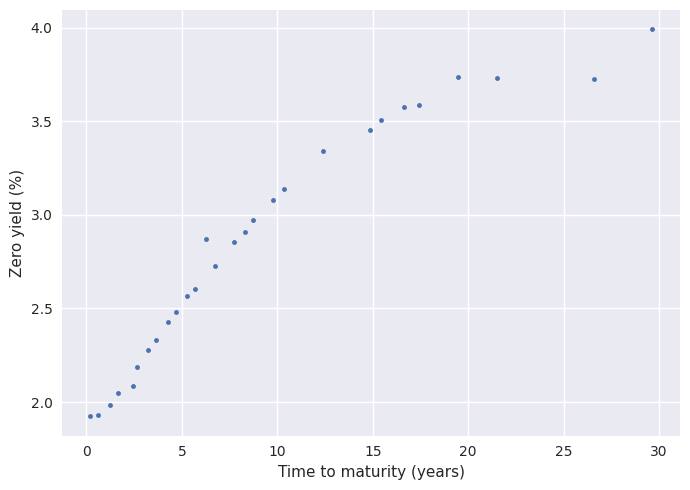

In [8]:
zero_yields = -np.log(discount_factors) / time_to_maturity

fig = plt.figure(figsize=(7, 5))

plt.plot(time_to_maturity, zero_yields * 100, '.')
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

fig.tight_layout()

plt.show()

In [9]:
yield_df = pd.DataFrame(columns=["TimeToMaturity", "ZeroYield"])
yield_df["TimeToMaturity"] = time_to_maturity
yield_df["ZeroYield"]      = zero_yields

yield_df.to_csv(example_root / "data" / "fi_yields_2026-02-02.csv", index=False)